<h2>Before you start</h2>
If this is the first time the pipeline is running on this machine, just run the cell below. It will copy startup.py from the BEARMIND folder into your local startup folder. This allows the code in startup.py to be executed automatically after each kernel restart (and removes the need to monotonously click through all setup cells after each reloading).

In [1]:
# you can (should) install natsort in env caiman
!pip install natsort

In [2]:
import shutil
import os

local_startup_dir = get_ipython().profile_dir.startup_dir
filedir = os.getcwd()
shutil.copy(os.path.join(filedir, 'startup.py'), os.path.join(local_startup_dir, 'startup.py'))

'C:\\Users\\admin\\.ipython\\profile_default\\startup\\startup.py'

<h2>Module 0</h2>
You need to specify the root folder and pathway pattern. Note that * is a wildcard for any symbol combination except slashes (i.e., for any folder name), so it is strongly recommended to use it here.<br/><br/>
NB!! Just in case, use double backslashes for folder separation, otherwise some symbols may be interpreted as escape sequences. 

In [3]:
config_data = {
    'ROOT': "C:\\Users\\admin\\Projects\\BOWL\\CalciumData\\Estimates",
    #'DATA_PATHWAY': 'legacy',
    'DATA_PATHWAY': 'bonsai',
    'TEMP_PATHWAY': "c:\\Users\\User\\caiman_data\\temp\\"
}

update_config(config_data)

In [4]:
CONFIG

{'ROOT': 'C:\\Users\\admin\\Projects\\BOWL\\CalciumData\\Estimates',
 'DATA_PATHWAY': 'bonsai',
 'CPUs': 28,
 'RAM': 256,
 'TEMP_PATHWAY': 'c:\\Users\\User\\caiman_data\\temp'}

In [5]:
create_mouse_configs(root=CONFIG['ROOT'])
create_session_configs(root=CONFIG['ROOT'])

<h2>Module 1</h2>
Manual video inspection. <br/>Open folder with miniscopic videos in a pop-up window, wait for loading and specify margins to be cropped by sliders or by keyboard, then save them by running the next cell. At the time, cropping .pickle files are to be created in these folders. Repeat for all folders with miniscopic videos you would like to analyze.   

In [31]:
#Manual file selection:
fnames = list(askopenfilenames(title = 'Select files for inspection', initialdir = CONFIG['ROOT'], filetypes = [('AVI files', '.avi')]))

data = LoadSelectedVideos(fnames)
w = DrawCropper(data, fname=fnames[0])

interactive(children=(IntSlider(value=1, description='x', layout=Layout(width='100%'), max=999), IntSlider(val…

Batch cropping and timestamp extraction.<br/>Miniscopic videos from folders with .pickle files are to be cropped and saved as _CR.tif in the root folder. There is no need for renaming of sigle-digit .avi files (like 0-9.avi to 00-09.avi)!<br/>
Also, along with video data, timestamps are to be copied from minicopic folders to the root folder. Do not delete them, they are nessesary for the further steps!

## Combined Modules 1-2-2.5

In [ ]:
#Batch crop
cpath_template = os.path.normpath(os.path.join(CONFIG['ROOT'], folder_structure, '*cropping.pickle'))
pick_names = glob(cpath_template)

print([get_session_name_from_path(fname) for fname in pick_names])
# TODO: read from mouse or sconfig only!

for name in pick_names:
    DoCropAndRewrite(name, sort = True, write_mp4 = True)
    extract_and_copy_ts(name)

#Automatic file selection
fnames = glob(os.path.join(CONFIG['ROOT'], '*_CR.tif'))
#OR, alternatively, you can use manual file selection:
#fnames = askopenfilenames(title = 'Select files for motion correction', initialdir = CONFIG['ROOT'], filetypes = [('TIFF files', '.tif')])

mc_dict = {
    'pw_rigid': False,         # flag for performing piecewise-rigid motion correction (otherwise just rigid)
    'max_shifts': (35, 35),    # maximum allowed rigid shift
    'gSig_filt': (8, 8),       # size of high pass spatial filtering, used in 1p data
    'strides': (48, 48),       # start a new patch for pw-rigid motion correction every x pixels
    'overlaps': (24, 24),      # overlap between pathes (size of patch strides+overlaps)
    'max_deviation_rigid': 15,  # maximum deviation allowed for patch with respect to rigid shifts
    'border_nan': 'copy',      # replicate values along the boundaries
    'use_cuda': True,          # Set to True in order to use GPU
    'memory_fact': CONFIG['RAM']/16.0,          # How much memory to allocate. 1 works for 16Gb, so 0.8 showd be optimized for 12Gb.
    'niter_rig': 1,
    'splits_rig': 20,          # for parallelization split the movies in  num_splits chuncks across time
                               # if none all the splits are processed and the movie is saved
    'num_splits_to_process_rig': None,
    'write_mp4': True} # intervals at which patches are laid out for motion correction  

for name in tqdm.tqdm(fnames):
    DoMotionCorrection(name, mc_dict)
    
    temp_pathway = CONFIG['TEMP_PATHWAY']
    sub_name = name.split('/')[-1]
    memmap_name = f'{temp_pathway}/{sub_name}'
    CleanMemmaps(memmap_name)

#%matplotlib ipympl
fnames = glob(os.path.join(CONFIG['ROOT'], '*_MC.tif'))
#fnames = askopenfilenames(title = 'Select files for corr image testing',
#                          initialdir = CONFIG['ROOT'],
#                          filetypes = [('TIFF files', '.tif')])

plot_gsig_range(fnames, maxframes=10000, min_gsig=3, max_gsig=6, step=5, dpi=300,
                    show_images=0, save_images=1)
plot_min_corr_and_pnr_range(fnames, maxframes=2000,
                            gsig_range=[3,4,5], pnr_range=[7,10,15],
                            mincorr_range=[0.85, 0.9, 0.95],
                            step=5, dpi=300,
                            show_images=0, save_images=1)

['LNOF_J01_1D', 'LNOF_J01_2D', 'LNOF_J01_3D', 'LNOF_J01_4D', 'LNOF_J05_1D', 'LNOF_J05_2D', 'LNOF_J05_3D', 'LNOF_J05_4D', 'LNOF_J06_1D', 'LNOF_J06_2D', 'LNOF_J06_3D', 'LNOF_J06_4D', 'LNOF_J12_1D', 'LNOF_J12_2D', 'LNOF_J12_3D', 'LNOF_J12_4D', 'LNOF_J14_1D', 'LNOF_J14_2D', 'LNOF_J14_3D', 'LNOF_J14_4D', 'LNOF_J18_1D', 'LNOF_J18_2D', 'LNOF_J18_3D', 'LNOF_J18_4D', 'LNOF_J19_1D', 'LNOF_J19_2D', 'LNOF_J19_3D', 'LNOF_J19_4D', 'LNOF_J20_1D', 'LNOF_J20_2D', 'LNOF_J20_3D', 'LNOF_J20_4D', 'LNOF_J21_1D', 'LNOF_J21_2D', 'LNOF_J21_3D', 'LNOF_J21_4D', 'LNOF_J23_1D', 'LNOF_J23_2D', 'LNOF_J23_3D', 'LNOF_J23_4D', 'LNOF_J24_1D', 'LNOF_J24_2D', 'LNOF_J24_3D', 'LNOF_J24_4D', 'LNOF_J25_1D', 'LNOF_J25_2D', 'LNOF_J25_3D', 'LNOF_J25_4D', 'LNOF_J28_1D', 'LNOF_J28_2D', 'LNOF_J28_3D', 'LNOF_J28_4D', 'LNOF_J30_1D', 'LNOF_J30_2D', 'LNOF_J30_3D', 'LNOF_J30_4D', 'LNOF_J42_1D', 'LNOF_J42_2D', 'LNOF_J42_3D', 'LNOF_J42_4D', 'LNOF_J52_1D', 'LNOF_J52_2D', 'LNOF_J52_3D', 'LNOF_J52_4D', 'LNOF_J53_1D', 'LNOF_J53_2D', 'LNOF_J53

  0%|          | 0/108 [00:00<?, ?it/s]

d:\LongNovelOpenField\CalciumData\1_Raw\LNOF_J01_1D\LNOF_J01_1D_0.avi - 1001 frames


  1%|          | 1/108 [00:02<03:46,  2.12s/it]

d:\LongNovelOpenField\CalciumData\1_Raw\LNOF_J01_1D\LNOF_J01_1D_1.avi - 1001 frames


...

 99%|█████████▉| 107/108 [01:54<00:01,  1.05s/it]

d:\LongNovelOpenField\CalciumData\1_Raw\LNOF_J57_1D\LNOF_J57_1D_107.avi - 217 frames


100%|██████████| 108/108 [01:54<00:00,  1.06s/it]


Moviepy - Building video d:\LongNovelOpenField\CalciumData\1_Raw\LNOF_J57_1D_CR.mp4.
Moviepy - Writing video d:\LongNovelOpenField\CalciumData\1_Raw\LNOF_J57_1D_CR.mp4



t:  14%|█▍        | 15171/107216 [00:43<04:08, 370.88it/s, now=None]

<h2>Module 2</h2>
Batch motion correction.<br/>All _CR.tif files in the root folder are to be automatically motion corrected with NoRMCorre routine [Pnevmatikakis, Giovanucci, 2017] with the parameters below and saved as _MC.tif files.

In [ ]:
#Automatic file selection
#fnames = glob(os.path.join(CONFIG['ROOT'], '*_CR.tif'))
#OR, alternatively, you can use manual file selection:
fnames = askopenfilenames(title = 'Select files for motion correction', initialdir = CONFIG['ROOT'], filetypes = [('TIFF files', '.tif')])

mc_dict = {
    'pw_rigid': False,         # flag for performing piecewise-rigid motion correction (otherwise just rigid)
    'max_shifts': (35, 35),    # maximum allowed rigid shift
    'gSig_filt': (8, 8),       # size of high pass spatial filtering, used in 1p data
    'strides': (48, 48),       # start a new patch for pw-rigid motion correction every x pixels
    'overlaps': (24, 24),      # overlap between pathes (size of patch strides+overlaps)
    'max_deviation_rigid': 15,  # maximum deviation allowed for patch with respect to rigid shifts
    'border_nan': 'copy',      # replicate values along the boundaries
    'use_cuda': True,          # Set to True in order to use GPU
    'memory_fact': CONFIG['RAM']/16.0,          # How much memory to allocate. 1 works for 16Gb, so 0.8 showd be optimized for 12Gb.
    'niter_rig': 1,
    'splits_rig': 20,          # for parallelization split the movies in  num_splits chuncks across time
                               # if none all the splits are processed and the movie is saved
    'num_splits_to_process_rig': None} # intervals at which patches are laid out for motion correction  

for name in tqdm.tqdm(fnames):
    DoMotionCorrection(name, mc_dict)
    
    temp_pathway = CONFIG['TEMP_PATHWAY']
    sub_name = name.split('/')[-1]
    memmap_name = f'{temp_pathway}/{sub_name}'
    CleanMemmaps(name)

In [ ]:
ms_name = 'H02'
session_name = 'NOF_H02_0D'
mc_to_config = {'mc_params': mc_dict}

ms_config_path = get_mouse_config_path(ms_name)
session_config_path = get_session_config_path(session_name)

#update_config(mc_to_config, cpath=ms_config_path)
update_config(mc_to_config, cpath=session_config_path)

<h3>Module 2.5 (optional)</h3>
Pre-test of various values of <i>gSig</i> parameter, which is used in the Module 3 and corresponds to a typical radius of a neuron in pixels.<br/>You can play with this parameter but you can use the default value of gSig = 6 as well. <br/> Calculation may take a while, so be patient!

Code snippet for manual calculation of imax for corrupted images

In [ ]:
#%matplotlib ipympl
fnames = glob(os.path.join(CONFIG['ROOT'], '*_MC.tif'))
#fnames = askopenfilenames(title = 'Select files for corr image testing',
#                          initialdir = CONFIG['ROOT'],
#                          filetypes = [('TIFF files', '.tif')])

plot_gsig_range(fnames, maxframes=10000, min_gsig=3, max_gsig=6, step=5, dpi=300,
                    show_images=0, save_images=1)
plot_min_corr_and_pnr_range(fnames, maxframes=2000,
                            gsig_range=[3,4,5], pnr_range=[5,7,10],
                            mincorr_range=[0.85, 0.9, 0.95],
                            step=5, dpi=300,
                            show_images=0, save_images=1)

In [1]:
session_name = ['HOS_D01_1D_1T', 'HOS_D03_1D_1T', 'HOS_D04_1D_1T', 'HOS_D07_1D_1T', 'HOS_D08_1D_1T', 'HOS_D11_1D_1T', 'HOS_D14_1D_1T', 'HOS_D17_1D_1T']
opt_gsig = [5,4,4,4,5,4,3,4]
min_corr = [0.95,0.95,0.9,0.9,0.95,0.9,0.9,0.9]
min_pnr = [10,10,7,15,7,10,15,7]

print(len(session_name), len(opt_gsig), len(min_corr), len(min_pnr))
for i, name in enumerate(session_name):
    gSiz = opt_gsig[i]*2+1
    cnmf_dict= {'fr': 30,                   # frame rate, frames per second (NOW RECALCULATED FOR EACH FILE FROM TIMESTAMP DATA)
                'decay_time': 1,            # typical duration of calcium transient 
                'method_init': 'corr_pnr',  # use this for 1 photon
                'K': None,                  # upper bound on number of components per patch, in general None
                'gSig': (opt_gsig[i], opt_gsig[i]),             # gaussian HALF-width of a 2D gaussian kernel (in pixels), which approximates a neuron
                'gSiz': (gSiz, gSiz),           # maximal radius of a neuron in pixels
                'merge_thr': 0.65,          # merging threshold, max correlation allowed
                'p': 1,                     # order of the autoregressive system
                'tsub': 1,                  # downsampling factor in time for initialization
                'ssub': 1,                  # downsampling factor in space for initialization
                'rf': 40,                   # half-size of the patches in pixels. e.g., if rf=40, patches are 80x80
                'stride': 25,               # amount of overlap between the patches in pixels(keep it at least large as gSiz, i.e 4 times the neuron size gSig) 
                'only_init': True,          # set it to True to run CNMF-E
                'nb': 0,                    # number of background components (rank) if positive, else exact ring model with following settings: nb= 0: Return background as b and W, gnb=-1: Return full rank background B, gnb<-1: Don't return background
                'nb_patch': 0,              # number of background components (rank) per patch if nb>0, else it is set automatically
                'method_deconvolution': 'oasis',       # could use 'cvxpy' alternatively
                'low_rank_background': None,           # None leaves background of each patch intact, True performs global low-rank approximation if gnb>0
                'update_background_components': True,  # sometimes setting to False improve the results
                'min_corr': min_corr[i],                        # min peak value from correlation image
                'min_pnr': min_pnr[i],                         # min peak to noise ratio from PNR image
                'normalize_init': False,               # just leave as is
                'center_psf': True,                    # leave as is for 1 photon
                'ssub_B': 2,                           # additional downsampling factor in space for background
                'ring_size_factor': 1.5,               # radius of ring is gSiz*ring_size_factor
                'del_duplicates': True,                # whether to remove duplicates from initialization
                'border_pix': 5,                       # number of pixels to not consider in the borders
                'min_SNR': 4,                          # adaptive way to set threshold on the transient size
                'rval_thr': 0.9,                       # threshold on space consistency           
                'use_cnn': False}                      # whether to use CNNs for event detection  

    session_config_path = get_session_config_path(session_name[i])
    cnmf_to_config = {'cnmf_params': cnmf_dict}
    update_config(cnmf_to_config, cpath=session_config_path)

8 8 8 8


FileNotFoundError: [Errno 2] No such file or directory: 'g:\\Projects\\BES\\SESSION_CONFIGS\\HOS_D01_1D_1T.json'

<h2>Module 3</h2>
Batch cnmf.<br/>All _MC.tif files in the root folder are to be automatically processed with CaImAn routine [Giovanucci et al., 2019] with the parameters below. Main parameters are gSig and gSiz for cell augmentation, then min_SNR as traces quality threshold. At the end, _estimates.pickle files are to be produced in the root folder. 

In [1]:
import time
#fnames = glob(os.path.join(CONFIG['ROOT'], '*_MC.tif'))
#OR, alternatively, you can use manual file selection:
fnames = askopenfilenames(title = 'Select files for batch cnmf', initialdir = CONFIG['ROOT'], filetypes = [('TIFF files', '.tif')])

for name in tqdm.tqdm(fnames):
    fps = get_fps_from_timestamps(name[:-4-6], default_fps=20, verbose=False)
    print('timestamps average FPS: ', fps)
    session_config_path = get_session_config_path(name[-20:-10])
    cnmf_config = read_config(name=session_config_path)
    cnmf_dict = cnmf_config['cnmf_params']
    #cnmf_dict.update({'fr': fps/1})
    #cnmf_dict.update({'tsub': 1})

    print(f"gsig: {cnmf_dict['gSig'][1]}, mincorr: {cnmf_dict['min_corr']}, minpnr: {cnmf_dict['min_pnr']}")
    out_name = name[:-4-6] + f'_estimates.pickle'
    print('estimate output name: ', out_name)
    DoCNMF(name,
           cnmf_dict,
           out_name=out_name,
           verbose=True,
           noise_ampl=1e-5)
    
    #CleanMemmaps(name)  
    temp_pathway = CONFIG['TEMP_PATHWAY']
    sub_name = name.split('/')[-1]
    memmap_name = f'{temp_pathway}/{sub_name}'
    
    err_cnt = 0
    while err_cnt < 100:
        try:
            CleanMemmaps(memmap_name)
            break
        except PermissionError:
            time.sleep(1)
            err_cnt += 1
    print('CleanMemmaps attemps:', err_cnt)

  0%|          | 0/1 [00:00<?, ?it/s]

timestamp found:  G:/Projects/BES/1_Raw\BES_H32_2D_2024_07_13_14_02_20_timestamp.csv
timestamps average FPS:  19.76
gsig: 4, mincorr: 0.95, minpnr: 12
estimate output name:  G:/Projects/BES/1_Raw/BES_H32_2D_estimates.pickle


In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
The local backend is an alias for the multiprocessing backend, and the alias may be removed in some future version of Caiman


Loading tif to memory...
Performing CNMF...
Source extracting...
Fitting...
Evaluating components...
Computing imax...
Saving result...
BES_H32_2D_CR_MC.tif cnmf-ed in 525.2s
CleanMemmaps attemps: 0


100%|██████████| 1/1 [08:46<00:00, 526.04s/it]


<h2>Module 4</h2>
User inspection of cnmf results.<br/>
Btw, at this stage, previously saved timestamps are to be merged with cnmf results.
By running the section below, you will be prompted to select estimtes file with cnmf results and then to interactively examine detected units (you can select both spatial and temporal components), you can select, merge and delete them, also you can seed new neurons (by PointDrawTool) for further re-run of CNMF with saved seeds. Finally, you can save (by pressing 'Save Results') spatial and temporal components as .tif and traces.csv files, respectively. Spatial components (aka filters) are to be stored in a separate folder (*_filters).

In [6]:
import os
os.environ['BOKEH_ALLOW_WS_ORIGIN'] = 'localhost:8889'  # Укажите порт вашего Jupyter Notebook, например, 8888

In [8]:
import time

root = CONFIG['ROOT']

fname = askopenfilename(title = 'Select estimates file for examination',
                        initialdir = root,
                        filetypes = [('estimates files', '*estimates.pickle')])

bkapp_kwargs = {
    'start_frame': 0,          # start from this frame
    'end_frame': 900000,        # end at this frame
    'downsampling': 15,         # take every 'x' frame
    'fill_alpha': 0.8,         # selected neuron transparency
    'ns_alpha': 0.3,          # non-selected neuron transparency
    'line_width': 0.8,         # border width
    'cthr': 0.35,              # coutour_thr from caiman (% of signal inside a patch), affects patch size
    'sort_order': 'up',            # sorting order
    'corr_thr': 0.6,           # threshold for truncated corr matrix
    'line_alpha': 0.8,         # border transparency
    'trace_line_width': 1,   # trace line width
    'trace_alpha': 0.7,          # trace transparency
    'size': 500,
    'button_width': 120,       # button width in pixels
    'verbose': 0,
    'enable_gpu_backend': 1,
    'oh_shit': 0
}

ExamineCells(fname, default_fps=20, bkapp_kwargs=bkapp_kwargs)

C:/Users/admin/Projects/BOWL/CalciumData/Estimates/BOWL_F14_1D_
[]


In [5]:
fnames = askopenfilenames(title = 'Select files for batch cnmf',
                          initialdir = CONFIG['ROOT'],
                          filetypes = [('TIFF files', '.tif')])

#fnames = glob(os.path.join(CONFIG['ROOT'], '*_MC.tif'))

ManualSeeds(fnames[0], size=800, cnmf_dict=None)

Redo cnmf with manually added seeds (optional).<br/>
NB!! By running the cell below, you will rewrite existing estimates files!!<br/>
Then you can return to the section above and inspect the rewritten estimates.

In [ ]:
s_names = glob(os.path.join(CONFIG['ROOT'], '*seeds.pickle'))
#OR, alternatively, you can use manual file selection:
#s_names = askopenfilenames(title = 'Select seeds files for re-CNMFing', initialdir = CONFIG['ROOT'], filetypes = [('seeds files', '*seeds.pickle')])


for s_name in s_names:
    base_name = s_name.partition('_seeds')[0][:-4]
    
    e_names = glob(base_name + '_estimates.pickle')
    tif_names = glob(base_name + '.tif')
    ReDoCNMF(s_name, e_name=None, tif_name=tif_names[0], cnmf_dict=cnmf_dict)
    CleanMemmaps(base_name)

## Test corr_function

In [23]:
# corr matrix extraction

fname = "C:/Users/admin/Projects/BOWL/CalciumData/Estimates/BOWL_D07_1D_estimates.pickle"
estimates = LoadEstimates(fname, default_fps=20)
comps_to_select = estimates.idx_components # good ones
sf = 0 #start frame
ef = 100000 #end frame
# CM = np.corrcoef(estimates.C[comps_to_select, sf:ef])
# np.fill_diagonal(CM, 0)
# CM[np.isnan(CM)] = 0

neurons = estimates.C[comps_to_select, sf:ef]
# neurons_test = neurons

C:/Users/admin/Projects/BOWL/CalciumData/Estimates/BOWL_D07_1D_
[]


### auto_inspect

In [28]:
from bm_examinator import LoadEstimates
from driada.experiment.wavelet_event_detection import extract_wvt_events, WVT_EVENT_DETECTION_PARAMS
from driada.experiment.neuron import Neuron, DEFAULT_T_RISE, DEFAULT_T_OFF, DEFAULT_FPS

from utils import *
import caiman as cm
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from caiman.components_evaluation import (
        evaluate_components_CNN, estimate_components_quality_auto,
        select_components_from_metrics, compute_eccentricity,
        compute_event_exceptionality)


from scipy.stats import median_abs_deviation


def get_hvals(traces):
    hvals = []
    for tr in traces:
        med = np.median(tr)
        meddev = median_abs_deviation(tr)
        hval = np.round(1.0 * len(np.where(tr >= med + 4 * meddev)[0]) / len(tr), 4)
        hvals.append(hval)

    return hvals


def get_contours(est, comps_to_select, cthr=0.3):
    estimates_data = est.A[:, comps_to_select]
    contours = cm.utils.visualization.get_contours(estimates_data,
                                                   dims=est.imax.shape,
                                                   thr=cthr)
    return contours


def calculate_perimeter(contour):
    dot_num = len(contour) - 1
    dots_dist = []
    
    while dot_num >= 0:
        dist = np.linalg.norm(contour[dot_num]-contour[dot_num-1])
        dots_dist.append(dist)
        
        dot_num -= 1

    perimeter = np.sum(dots_dist)
    return perimeter        
        

def get_circularities(est, comps_to_select, cthr=0.3):
    contours = get_contours(est, comps_to_select, cthr=cthr)
    circularities = []

    for i in range(len(contours):
        contour = contours[i]["coordinates"]

        area = calculate_polygon_area(contour)
        perimeter = calculate_perimeter(contour)

        circularity = perimeter**2/(4*np.pi*area)
        circularities.append(circularity)

    circularities = np.array(circularities)
    return circularities


def get_spike_based_snr(times, traces, fps=DEFAULT_FPS, t_rise=DEFAULT_T_RISE, t_off=DEFAULT_T_OFF):
    st_ev_inds, end_ev_inds, all_ridges = extract_wvt_events(traces, wvt_kwargs=WVT_EVENT_DETECTION_PARAMS)
    for i, tr in enumerate(traces[:1]):
        event_starts = np.array(st_ev_inds[i]).astype(int)
        sp_ampl = np.zeros(len(tr))
        sp = np.zeros(len(tr))

        sp[event_starts] = 1
        sp_ampl[event_starts] = tr[event_starts]

        neuron = Neuron(i,
                        tr,
                        sp,
                        default_t_rise=t_rise,
                        default_t_off=t_off,
                        fps=fps,
                        fit_individual_t_off=False,
                        seed=None)

        restored = neuron.get_restored_calcium(sp_ampl, t_rise, t_off)
        snr = neuron.get_snr()
        mad = neuron.get_mad()
        err = neuron.ca_mse_error(t_off, tr, sp, t_rise)

        print(snr, mad, err)

    return snr, mad, err, restored, tr


def estimates_to_metrics(fname, fps, comps_to_select=[], cthr=0.3, corr_thr=0.6, sf=None, ef=None, ds=1):
    est = LoadEstimates(fname, default_fps=fps)
    print('loaded estimates')

    if len(comps_to_select) == 0:
        comps_to_select = est.idx_components

    n_cells = len(comps_to_select)
    if n_cells == 0:
        return {}

    if sf is None:
        sf = 0
    if ef is None:
        ef = est.C.shape[1]

    traces = [(tr - min(tr)) / (np.max(tr) - np.min(tr)) + i for i, tr in
              enumerate(est.C[comps_to_select, sf:ef][:, ::ds])]
    times = [est.time[sf:ef][::ds] for _ in range(n_cells)]

    contours = get_contours(est, comps_to_select, cthr=cthr)
    areas = []
    centers = []
    for i, comp in enumerate(comps_to_select):
        coors = contours[i]["coordinates"]
        area = calculate_polygon_area(coors)
        areas.append(area)
        centers.append(contours[i]["CoM"])

    caiman_snrs = est.SNR_comp[comps_to_select]
    caiman_r_scores = est.r_values[comps_to_select]

    #snr, mad, err, restored, tr = get_spike_based_snr(times, traces, fps=fps)

    metrics = {
        'component_idx': comps_to_select,
        'area': areas,
        'center': centers,
        'caiman_snr': caiman_snrs,
        'caiman_r_score': caiman_r_scores
    }
    metrics_df = pd.DataFrame(metrics)
    return metrics_df


fname = "D://Projects//estim_data//NOF_H01_3D_CR_MC_4_1_0.85_estimates.pickle"
fps=20
df = estimates_to_metrics(fname, fps)
print(df)

ImportError: cannot import name 'get_tags' from 'sklearn.utils._tags' (C:\Users\admin\anaconda3\envs\caiman3\lib\site-packages\sklearn\utils\_tags.py)

### auto_classify

In [ ]:
def area_check(series, pxlthr_area):
    metric = (series.area > pxlthr_area)
    return metric

def circularity_check(series, circ_thr):
    metric = (series.circularity <= circ_thr)
    return metric

def final_check(df, circ_thr, pxlthr_area=3, pxlthr_distance=10):
    # corrss = df['corr'].values
    series_num = df.shape[0]
    df = df.assign(new_column=df['delete'] + df['merge'])
    
    for string_num in range[series_num]:
        string = df.iloc[string_num]
        
        ### parameters
        area = area_check(string, pxlthr_area)
        circle = circularity_check()

        delete = not (area and circle)
        ###
        
        df.iloc[string_num].delete = int(delete)

    return df


In [ ]:
cm.utils.visualization.center_of_mass(

In [6]:
v = 7 * np.nan
v

nan

### CorrSnatchedSpikes_final

In [18]:
from scipy.stats import spearmanr
import time

def CorrSnatchedSpikes(neurons, corr_threshold, match_threshold, fps=30, session_time=15, sessions_num=5):

    corr_mtx_sessions = []
    side = len(neurons)
    
    for session in range(sessions_num):
        session_length = fps*session_time*60
        ts_start = session * session_length

        corr_mtx = np.corrcoef(neurons[:, ts_start:ts_start+session_length-1])
        corr_mtx = np.where(corr_mtx >= corr_threshold, 1, 0)
    
        corr_mtx_sessions.append(corr_mtx)

    corr_mtx_sessions = np.array(corr_mtx_sessions)
    match_mtx = np.sum(corr_mtx_sessions, axis=0) / sessions_num
    match_mtx = np.where(match_mtx >= match_threshold, match_mtx, 0)
        
    return match_mtx

time1 = time.time()
match_mtx = CorrSnatchedSpikes(neurons_test, corr_threshold=0.6, match_threshold=0.6)
time2 = time.time()
print(time2-time1)

0.9746298789978027


In [11]:
def CorrSnatchedSpikes_final(neurons, corr_threshold, match_threshold, fps=30, session_time=15, sessions_num=5):

    match_threshold /= sessions_num
    corr_num = len(neurons)
    corr_mtx_sessions = []
    
    for session in range(sessions_num):
        session_length = fps*session_time*60
        ts_start = session * session_length

        corr_mtx = np.corrcoef(neurons[:, ts_start:ts_start+session_length-1])
        corr_mtx = np.where(corr_mtx >= corr_threshold, 1, 0)
    
        corr_mtx_sessions.append(corr_mtx)

    corr_mtx_sessions = np.array(corr_mtx_sessions)
    match_mtx = np.sum(corr_mtx_sessions, axis=0) / sessions_num
    match_mtx_crop = np.where(match_mtx >= match_threshold, match_mtx, 0)

    CM = match_mtx_crop 
    np.fill_diagonal(CM, 0)
    CM[np.isnan(CM)] = 0

    TCM = CM.copy()
    TCM[np.where(TCM < match_threshold)] = 0

    nontrivial_ccs = [comp for comp in list(get_ccs_from_adj(TCM)) if len(comp) > 1]

    group_corr_scores = np.zeros(len(nontrivial_ccs))
    corr_scores = np.zeros(corr_num)
    corr_groups = np.zeros(corr_num)
    for i, group in enumerate(nontrivial_ccs):
        ordered = np.array(sorted(list(group)))
        subnetwork = CM[ordered, :][:, ordered]  # we take corr values from initial corr matrix
        nc = len(ordered)
        group_density = np.sum(subnetwork) / (nc ** 2 - nc)
        group_corr_scores[i] = group_density
        #group_av_nnz = np.mean(subnetwork[np.where(subnetwork != 0)])

    sorted_nontrivial_ccs = [nontrivial_ccs[i] for i in np.argsort(group_corr_scores)[::-1]] # sort components from highest to lowest score
    sorted_group_corr_scores = sorted(group_corr_scores)
    for i, group in enumerate(sorted_nontrivial_ccs):
        for neuron in group:
            corr_scores[neuron] = sorted_group_corr_scores[i]
            corr_groups[neuron] = len(sorted_group_corr_scores) - i + 1 # big group number = high corr score
        
    return corr_groups, match_mtx

out = CorrSnatchedSpikes_final(neurons, corr_threshold=0.6, match_threshold=3)

out[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 7.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 8., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

### heatmaps

Вычисление хитмапы...


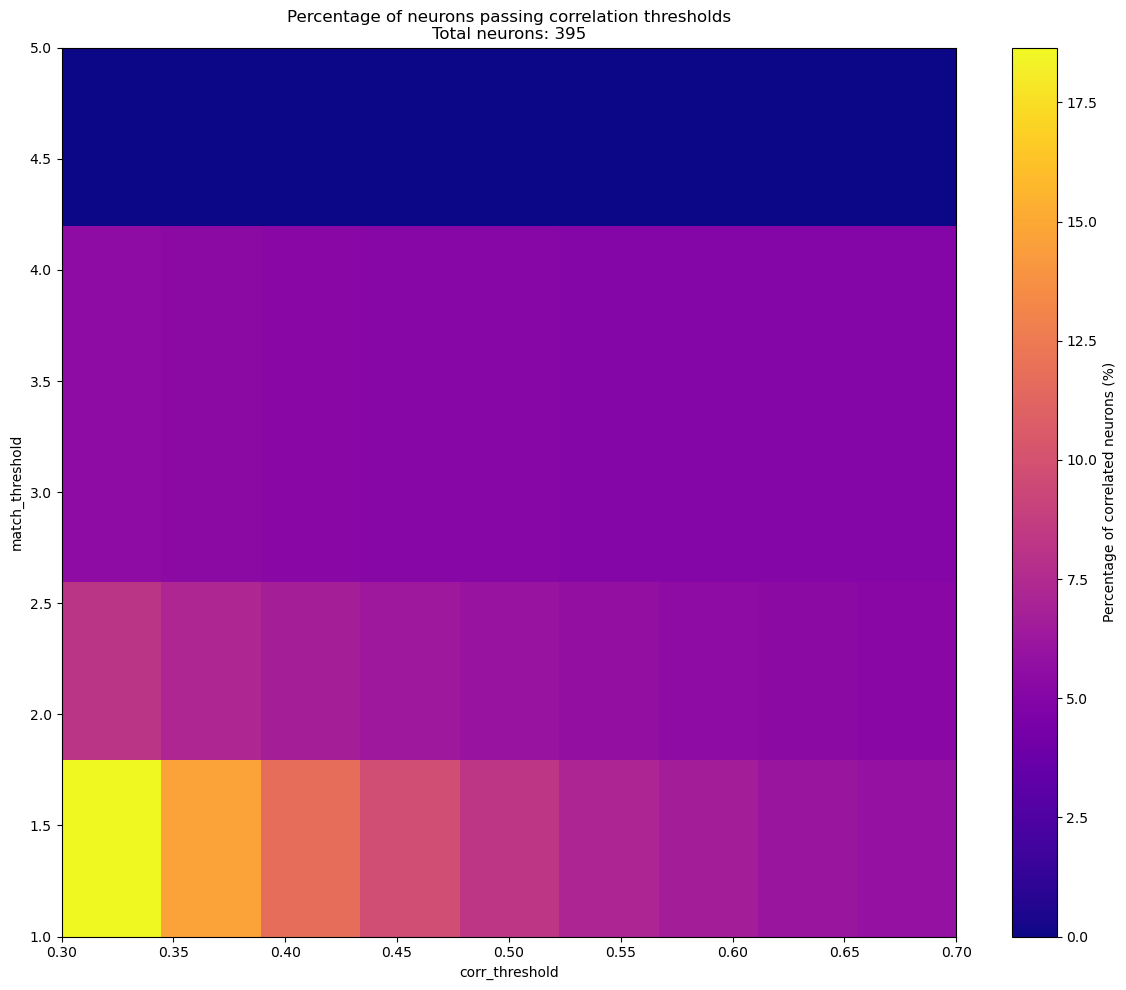

(array([[18.646734  , 14.66388907, 11.74694457,  9.72955891,  8.24632784,
          7.20963588,  6.63561642,  6.1753473 ,  5.87756292],
        [ 8.22297811,  7.21852022,  6.74102631,  6.27827684,  5.99631356,
          5.68916584,  5.49431251,  5.40018456,  5.29228986],
        [ 5.5175936 ,  5.42386969,  5.26801318,  5.16976655,  5.10740279,
          5.09483843,  5.0696163 ,  5.03154605,  5.03154605],
        [ 5.5175936 ,  5.42386969,  5.26801318,  5.16976655,  5.10740279,
          5.09483843,  5.0696163 ,  5.03154605,  5.03154605],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ]]),
 array([0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 ]),
 array([1., 2., 3., 4., 5.]))

In [213]:
from matplotlib.animation import FFMpegWriter
import matplotlib.animation as animation

def create_correlation_heatmap(neurons_test):
    """
    Создает хитмапу с осями corr_threshold и match_threshold,
    показывающую процент нейронов, прошедших пороги
    """
    # Параметры для осей
    corr_thresholds = np.arange(0.3, 0.75, 0.05)
    match_thresholds = np.arange(0.2, 1.2, 0.2)
    
    # Получаем общее количество нейронов
    # Предполагаем, что neurons_test - это матрица активности нейронов
    if hasattr(neurons_test, 'shape'):
        total_neurons = neurons_test.shape[0]  # если это матрица (нейроны x время)
    else:
        # Если это список или другой формат, нужно адаптировать
        total_neurons = len(neurons_test)
    
    # Создаем матрицу для хитмапы
    heatmap_data = np.zeros((len(match_thresholds), len(corr_thresholds)))
    
    print("Вычисление хитмапы...")
    # Заполняем матрицу данными
    for i, corr_thresh in enumerate(corr_thresholds):
        for j, match_thresh in enumerate(match_thresholds):
            # Вычисляем матрицу корреляции
            match_mtx = CorrSnatchedSpikes(neurons_test, 
                                         corr_threshold=corr_thresh, 
                                         match_threshold=match_thresh)
            
            # Подсчитываем количество коррелированных нейронов
            # (нейроны, которые имеют хотя бы одну значимую корреляцию)
            correlated_neurons = np.sum((match_mtx > 0) & (match_mtx < 1))
            
            # Вычисляем процент от общего числа нейронов
            percentage = np.sqrt(correlated_neurons / total_neurons**2) * 100
            
            # Сохраняем в матрицу (инвертируем j для правильной ориентации)
            heatmap_data[j, i] = percentage
    
    # Создаем хитмапу
    plt.figure(figsize=(12, 10))

    match_thresholds *= 5
    
    # Отображаем хитмапу
    im = plt.imshow(heatmap_data, cmap='plasma', aspect='auto', 
                   extent=[corr_thresholds[0], corr_thresholds[-1], 
                          match_thresholds[0], match_thresholds[-1]],
                   origin='lower')
    
    # Добавляем цветовую шкалу
    cbar = plt.colorbar(im, label='Percentage of correlated neurons (%)')
    
    # Настраиваем оси и заголовок
    plt.xlabel('corr_threshold')
    plt.ylabel('match_threshold')
    plt.title('Percentage of neurons passing correlation thresholds\n' +
              f'Total neurons: {total_neurons}')
    
    plt.tight_layout()
    plt.show()
    
    return heatmap_data, corr_thresholds, match_thresholds

create_correlation_heatmap(neurons_test)

Вычисление хитмапы кластеров...


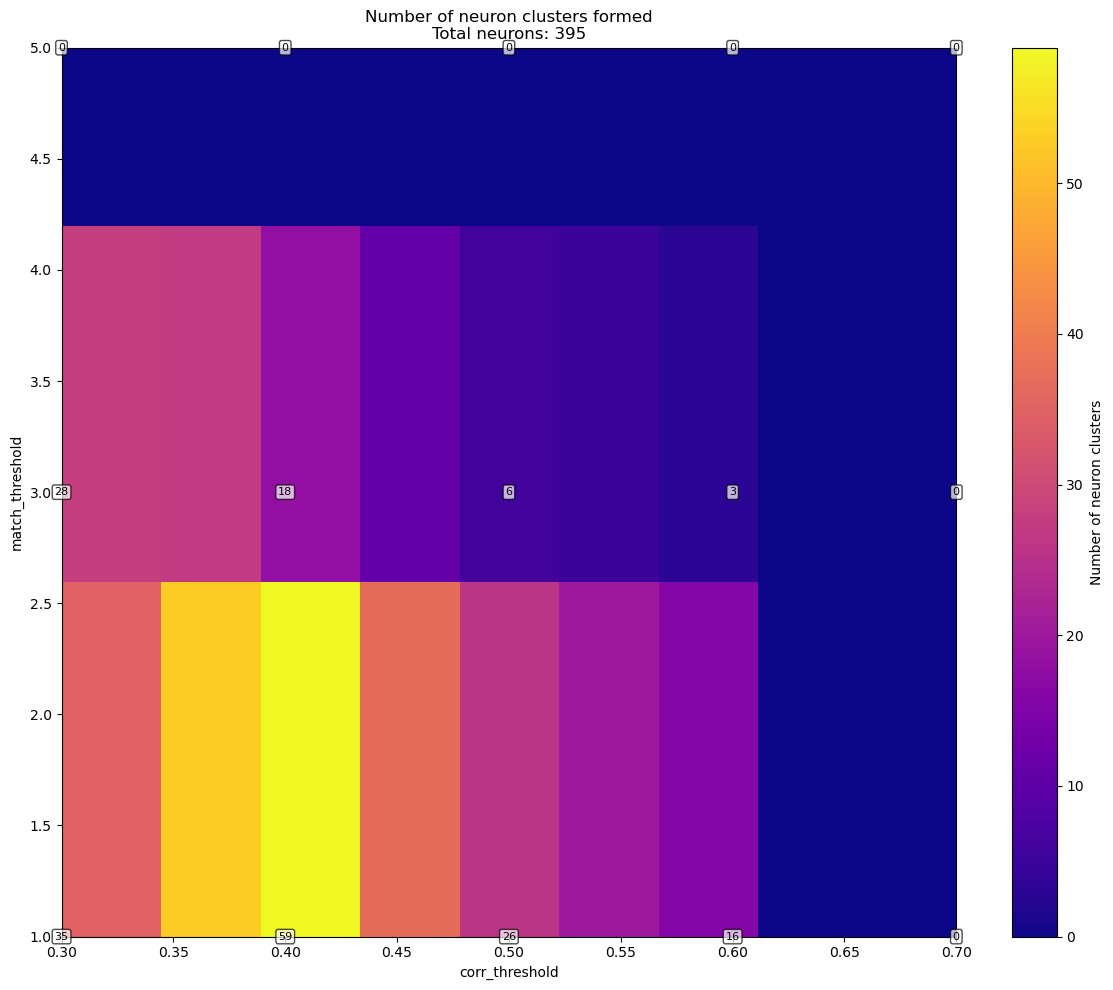

(array([[35., 53., 59., 37., 26., 20., 16.,  0.,  0.],
        [35., 53., 59., 37., 26., 20., 16.,  0.,  0.],
        [28., 27., 18., 11.,  6.,  5.,  3.,  0.,  0.],
        [28., 27., 18., 11.,  6.,  5.,  3.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]]),
 array([0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 ]),
 array([1., 2., 3., 4., 5.]))

In [214]:
def create_cluster_heatmap(neurons_test):
    """
    Создает хитмапу с осями corr_threshold и match_threshold,
    показывающую количество кластеров нейронов
    """
    # Параметры для осей
    corr_thresholds = np.arange(0.3, 0.75, 0.05)
    match_thresholds = np.arange(0.2, 1.2, 0.2)
    
    # Получаем общее количество нейронов
    if hasattr(neurons_test, 'shape'):
        total_neurons = neurons_test.shape[0]
        comps_to_select = np.arange(total_neurons)
    else:
        total_neurons = len(neurons_test)
        comps_to_select = np.arange(total_neurons)
    
    # Создаем матрицу для хитмапы (количество кластеров)
    cluster_heatmap_data = np.zeros((len(match_thresholds), len(corr_thresholds)))
    
    print("Вычисление хитмапы кластеров...")
    
    # Заполняем матрицу данными
    for i, corr_thresh in enumerate(corr_thresholds):
        for j, match_thresh in enumerate(match_thresholds):
            try:
                # Вычисляем матрицу корреляции
                CM = CorrSnatchedSpikes(neurons_test, 
                                      corr_threshold=corr_thresh, 
                                      match_threshold=match_thresh)
                
                # Добавляем блок анализа кластеров
                np.fill_diagonal(CM, 0)
                CM[np.isnan(CM)] = 0

                TCM = CM.copy()
                TCM[np.where(TCM < corr_thresh)] = 0

                nontrivial_ccs = [comp for comp in list(get_ccs_from_adj(TCM)) if len(comp) > 1]

                group_corr_scores = np.zeros(len(nontrivial_ccs))
                corr_scores = np.zeros(len(comps_to_select))
                corr_groups = np.zeros(len(comps_to_select))
                
                for k, group in enumerate(nontrivial_ccs):
                    ordered = np.array(sorted(list(group)))
                    subnetwork = CM[ordered, :][:, ordered]  # берем значения корреляции из исходной матрицы
                    nc = len(ordered)
                    group_density = np.sum(subnetwork) / (nc ** 2 - nc)
                    group_corr_scores[k] = group_density

                sorted_nontrivial_ccs = [nontrivial_ccs[k] for k in np.argsort(group_corr_scores)[::-1]] # сортируем компоненты от высшего к низшему score
                sorted_group_corr_scores = sorted(group_corr_scores)
                
                for k, group in enumerate(sorted_nontrivial_ccs):
                    for neuron in group:
                        corr_scores[neuron] = sorted_group_corr_scores[k]
                        corr_groups[neuron] = len(sorted_group_corr_scores) - k + 1 # большой номер группы = высокий corr score
                
                # Сохраняем количество нетривиальных кластеров (размер > 1)
                cluster_heatmap_data[j, i] = len(nontrivial_ccs)
                
            except Exception as e:
                print(f"Ошибка при corr_thresh={corr_thresh:.2f}, match_thresh={match_thresh:.2f}: {e}")
                cluster_heatmap_data[j, i] = 0
    
    # Создаем хитмапу
    plt.figure(figsize=(12, 10))

    match_thresholds *= 5
    
    # Отображаем хитмапу
    im = plt.imshow(cluster_heatmap_data, cmap='plasma', aspect='auto', 
                   extent=[corr_thresholds[0], corr_thresholds[-1], 
                          match_thresholds[0], match_thresholds[-1]],
                   origin='lower')
    
    # Добавляем цветовую шкалу
    cbar = plt.colorbar(im, label='Number of neuron clusters')
    
    # Настраиваем оси и заголовок
    plt.xlabel('corr_threshold')
    plt.ylabel('match_threshold')
    plt.title('Number of neuron clusters formed\n' +
              f'Total neurons: {total_neurons}')
    
    # Добавляем аннотации с значениями
    threshold_step = 2
    for i in range(0, len(corr_thresholds), threshold_step):
        for j in range(0, len(match_thresholds), threshold_step):
            value = cluster_heatmap_data[j, i]
            plt.text(corr_thresholds[i], match_thresholds[j], 
                    f'{int(value)}', 
                    ha='center', va='center', fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return cluster_heatmap_data, corr_thresholds, match_thresholds

create_cluster_heatmap(neurons_test)

Вычисление хитмапы среднего размера кластеров...


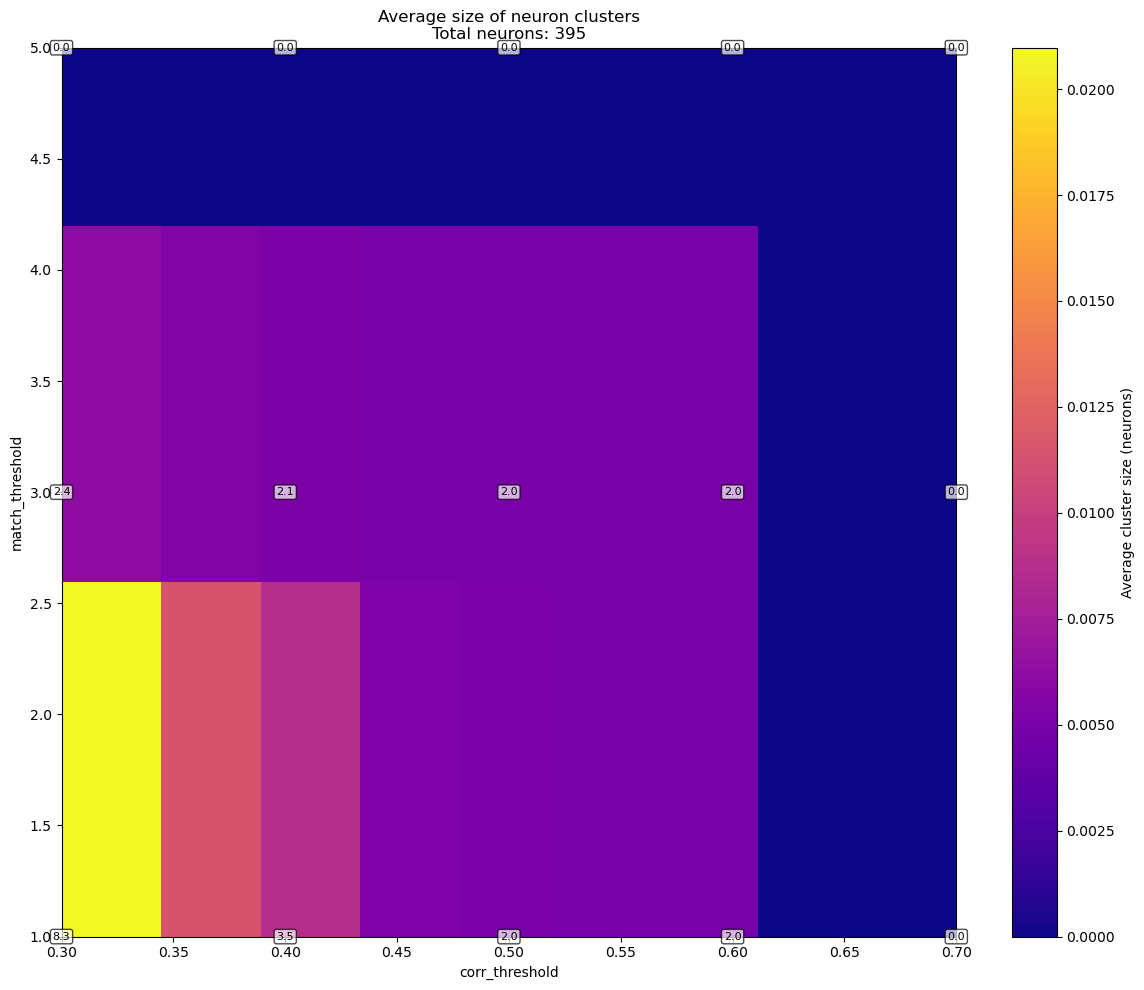

(array([[0.02097649, 0.01146406, 0.00875349, 0.00533698, 0.00516066,
         0.00506329, 0.00506329, 0.        , 0.        ],
        [0.02097649, 0.01146406, 0.00875349, 0.00533698, 0.00516066,
         0.00506329, 0.00506329, 0.        , 0.        ],
        [0.00614828, 0.00553211, 0.00520394, 0.00506329, 0.00506329,
         0.00506329, 0.00506329, 0.        , 0.        ],
        [0.00614828, 0.00553211, 0.00520394, 0.00506329, 0.00506329,
         0.00506329, 0.00506329, 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        ]]),
 array([0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 ]),
 array([1., 2., 3., 4., 5.]))

In [215]:
def create_avg_cluster_size_heatmap(neurons_test):
    """
    Создает хитмапу с осями corr_threshold и match_threshold,
    показывающую средний размер кластеров нейронов
    """
    # Параметры для осей
    corr_thresholds = np.arange(0.3, 0.75, 0.05)
    match_thresholds = np.arange(0.2, 1.2, 0.2)
    
    # Получаем общее количество нейронов
    if hasattr(neurons_test, 'shape'):
        total_neurons = neurons_test.shape[0]
        comps_to_select = np.arange(total_neurons)
    else:
        total_neurons = len(neurons_test)
        comps_to_select = np.arange(total_neurons)
    
    # Создаем матрицу для хитмапы (средний размер кластеров)
    avg_cluster_size_data = np.zeros((len(match_thresholds), len(corr_thresholds)))
    avg_cluster_size_data_labels = np.zeros((len(match_thresholds), len(corr_thresholds)))
    
    print("Вычисление хитмапы среднего размера кластеров...")
    
    # Заполняем матрицу данными
    for i, corr_thresh in enumerate(corr_thresholds):
        for j, match_thresh in enumerate(match_thresholds):
            try:
                # Вычисляем матрицу корреляции
                CM = CorrSnatchedSpikes(neurons_test, 
                                      corr_threshold=corr_thresh, 
                                      match_threshold=match_thresh)
                
                # Анализ кластеров
                np.fill_diagonal(CM, 0)
                CM[np.isnan(CM)] = 0

                TCM = CM.copy()
                TCM[np.where(TCM < corr_thresh)] = 0

                nontrivial_ccs = [comp for comp in list(get_ccs_from_adj(TCM)) if len(comp) > 1]

                # Вычисляем средний размер кластеров
                if len(nontrivial_ccs) > 0:
                    cluster_sizes = [len(comp) for comp in nontrivial_ccs]
                    avg_cluster_sizes = np.mean(cluster_sizes) / total_neurons
                    avg_cluster_size_labels = np.mean(cluster_sizes)
                else:
                    avg_cluster_size_labels = 0
                    avg_cluster_sizes = 0
                
                # Сохраняем средний размер кластеров
                avg_cluster_size_data[j, i] = avg_cluster_sizes
                avg_cluster_size_data_labels[j, i] = avg_cluster_size_labels
                
            except Exception as e:
                print(f"Ошибка при corr_thresh={corr_thresh:.2f}, match_thresh={match_thresh:.2f}: {e}")
                avg_cluster_size_data[j, i] = 0
                avg_cluster_size_data_labels[j, i] = 0
    
    # Создаем хитмапу
    plt.figure(figsize=(12, 10))
    match_thresholds *= 5
    # Отображаем хитмапу
    im = plt.imshow(avg_cluster_size_data, cmap='plasma', aspect='auto', 
                   extent=[corr_thresholds[0], corr_thresholds[-1], 
                          match_thresholds[0], match_thresholds[-1]],
                   origin='lower')
    
    # Добавляем цветовую шкалу
    cbar = plt.colorbar(im, label='Average cluster size (neurons)')
    
    # Настраиваем оси и заголовок
    plt.xlabel('corr_threshold')
    plt.ylabel('match_threshold')
    plt.title('Average size of neuron clusters\n' +
              f'Total neurons: {total_neurons}')
    
    # Добавляем аннотации с значениями
    threshold_step = 2
    for i in range(0, len(corr_thresholds), threshold_step):
        for j in range(0, len(match_thresholds), threshold_step):
            value = avg_cluster_size_data_labels[j, i]
            plt.text(corr_thresholds[i], match_thresholds[j], 
                    f'{value:.1f}', 
                    ha='center', va='center', fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return avg_cluster_size_data, corr_thresholds, match_thresholds

create_avg_cluster_size_heatmap(neurons_test)

Вычисление хитмапы максимального размера кластеров...


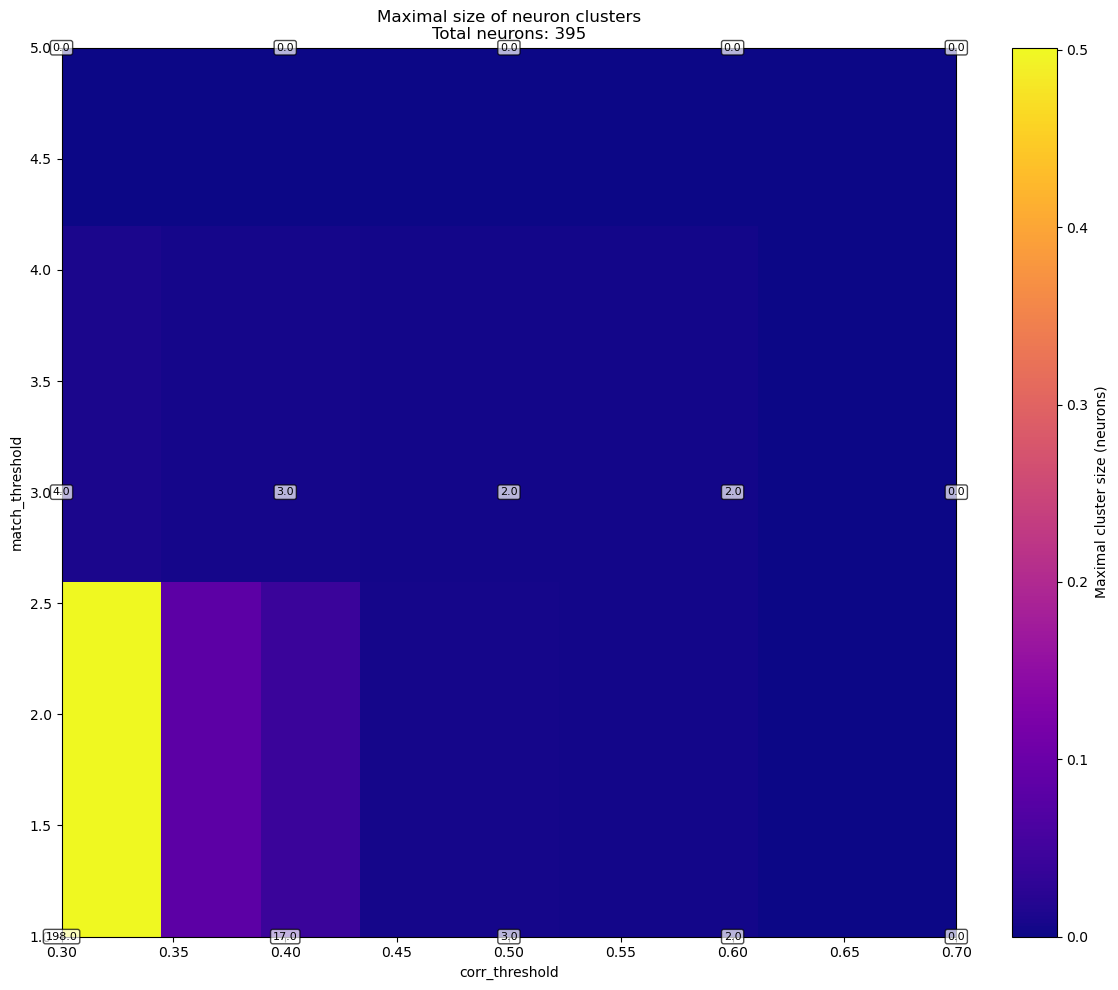

(array([[0.50126582, 0.0835443 , 0.04303797, 0.00759494, 0.00759494,
         0.00506329, 0.00506329, 0.        , 0.        ],
        [0.50126582, 0.0835443 , 0.04303797, 0.00759494, 0.00759494,
         0.00506329, 0.00506329, 0.        , 0.        ],
        [0.01012658, 0.00759494, 0.00759494, 0.00506329, 0.00506329,
         0.00506329, 0.00506329, 0.        , 0.        ],
        [0.01012658, 0.00759494, 0.00759494, 0.00506329, 0.00506329,
         0.00506329, 0.00506329, 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        ]]),
 array([0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 ]),
 array([1., 2., 3., 4., 5.]))

In [216]:
def create_avg_cluster_size_heatmap(neurons_test):
    """
    Создает хитмапу с осями corr_threshold и match_threshold,
    показывающую средний размер кластеров нейронов
    """
    # Параметры для осей
    corr_thresholds = np.arange(0.3, 0.75, 0.05)
    match_thresholds = np.arange(0.2, 1.2, 0.2)
    
    # Получаем общее количество нейронов
    if hasattr(neurons_test, 'shape'):
        total_neurons = neurons_test.shape[0]
        comps_to_select = np.arange(total_neurons)
    else:
        total_neurons = len(neurons_test)
        comps_to_select = np.arange(total_neurons)
    
    # Создаем матрицу для хитмапы (средний размер кластеров)
    avg_cluster_size_data = np.zeros((len(match_thresholds), len(corr_thresholds)))
    avg_cluster_size_data_labels = np.zeros((len(match_thresholds), len(corr_thresholds)))
    
    print("Вычисление хитмапы максимального размера кластеров...")
    
    # Заполняем матрицу данными
    for i, corr_thresh in enumerate(corr_thresholds):
        for j, match_thresh in enumerate(match_thresholds):
            try:
                # Вычисляем матрицу корреляции
                CM = CorrSnatchedSpikes(neurons_test, 
                                      corr_threshold=corr_thresh, 
                                      match_threshold=match_thresh)
                
                # Анализ кластеров
                np.fill_diagonal(CM, 0)
                CM[np.isnan(CM)] = 0

                TCM = CM.copy()
                TCM[np.where(TCM < corr_thresh)] = 0

                nontrivial_ccs = [comp for comp in list(get_ccs_from_adj(TCM)) if len(comp) > 1]

                # Вычисляем средний размер кластеров
                if len(nontrivial_ccs) > 0:
                    cluster_sizes = [len(comp) for comp in nontrivial_ccs]
                    avg_cluster_sizes = np.max(cluster_sizes) / total_neurons
                    avg_cluster_size_labels = np.max(cluster_sizes)
                else:
                    avg_cluster_size_labels = 0
                    avg_cluster_sizes = 0
                
                # Сохраняем средний размер кластеров
                avg_cluster_size_data[j, i] = avg_cluster_sizes
                avg_cluster_size_data_labels[j, i] = avg_cluster_size_labels
                
            except Exception as e:
                print(f"Ошибка при corr_thresh={corr_thresh:.2f}, match_thresh={match_thresh:.2f}: {e}")
                avg_cluster_size_data[j, i] = 0
                avg_cluster_size_data_labels[j, i] = 0
    
    # Создаем хитмапу
    plt.figure(figsize=(12, 10))
    match_thresholds *= 5
    # Отображаем хитмапу
    im = plt.imshow(avg_cluster_size_data, cmap='plasma', aspect='auto', 
                   extent=[corr_thresholds[0], corr_thresholds[-1], 
                          match_thresholds[0], match_thresholds[-1]],
                   origin='lower')
    
    # Добавляем цветовую шкалу
    cbar = plt.colorbar(im, label='Maximal cluster size (neurons)')
    
    # Настраиваем оси и заголовок
    plt.xlabel('corr_threshold')
    plt.ylabel('match_threshold')
    plt.title('Maximal size of neuron clusters\n' +
              f'Total neurons: {total_neurons}')
    
    # Добавляем аннотации с значениями
    threshold_step = 2
    for i in range(0, len(corr_thresholds), threshold_step):
        for j in range(0, len(match_thresholds), threshold_step):
            value = avg_cluster_size_data_labels[j, i]
            plt.text(corr_thresholds[i], match_thresholds[j], 
                    f'{value:.1f}', 
                    ha='center', va='center', fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return avg_cluster_size_data, corr_thresholds, match_thresholds

create_avg_cluster_size_heatmap(neurons_test)

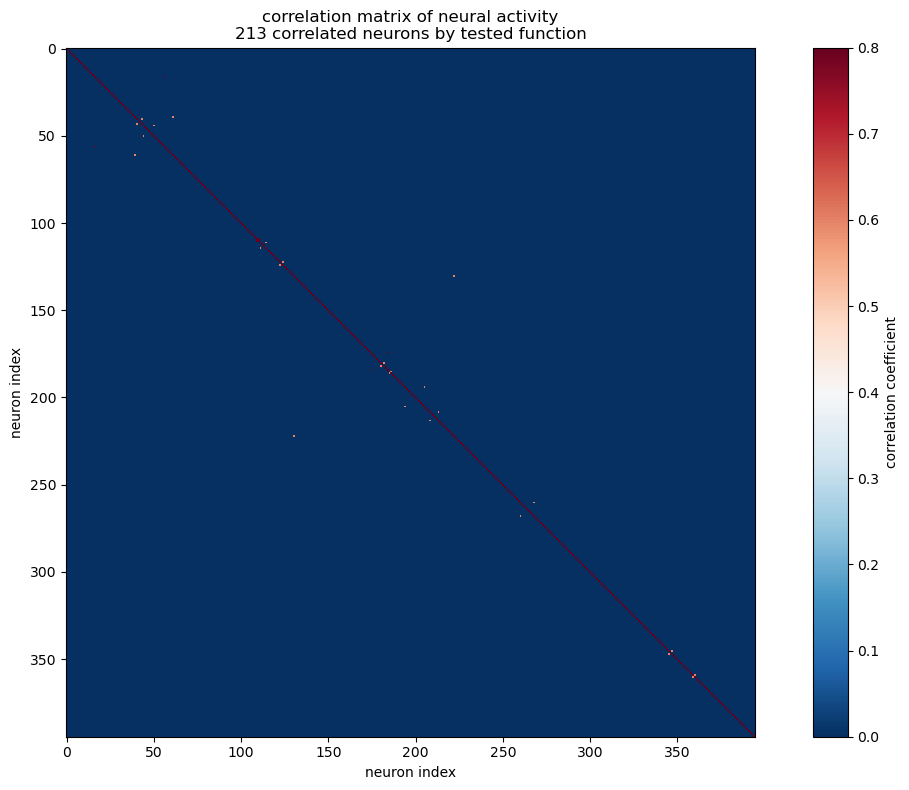

213


In [138]:
count_test = np.sum((match_mtx > 0) & (match_mtx < 1))

plt.figure(figsize=(12, 8))
plt.imshow(match_mtx, cmap='RdBu_r', interpolation='nearest')
plt.colorbar(label='correlation coefficient')
plt.title(f'correlation matrix of neural activity\n{int(count_test/2)} correlated neurons by tested function')
plt.xlabel('neuron index')
plt.ylabel('neuron index')
plt.tight_layout()
plt.show()

print(int(count_test/2))

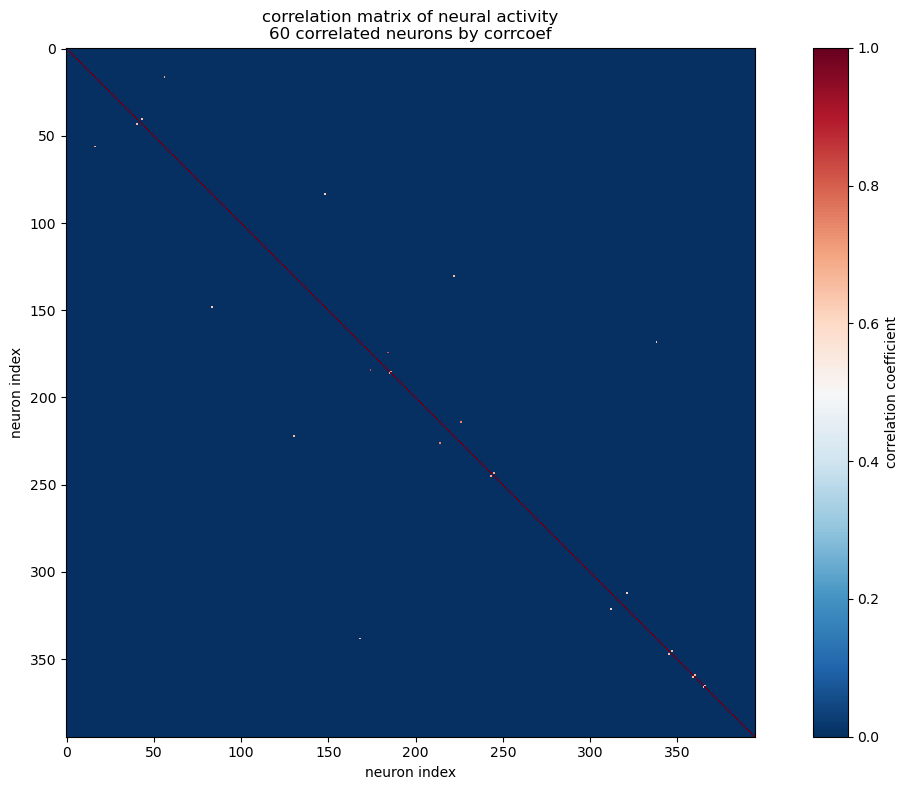

60


In [139]:
corr_mtxcoef = np.corrcoef(neurons)
corr_mtxcoef = np.where(corr_mtxcoef >= 0.6, corr_mtxcoef, 0)
count_corr = np.sum((corr_mtxcoef > 0) & (corr_mtxcoef < 1))

plt.figure(figsize=(12, 8))
plt.imshow(corr_mtxcoef, cmap='RdBu_r', interpolation='nearest')
plt.colorbar(label='correlation coefficient')
plt.title(f'correlation matrix of neural activity\n{int(count_corr/2)} correlated neurons by corrcoef')
plt.xlabel('neuron index')
plt.ylabel('neuron index')
plt.tight_layout()
plt.show()

print(int(count_corr/2))

### new_functions

In [14]:
def EstimatesToSrcFast_corrsess(estimates, comps_to_select=[], cthr=0.3, corr_thr=0.6, sf=None, ef=None, ds=1):
    if len(comps_to_select) == 0:
        comps_to_select = estimates.idx_components

    n_cells = len(comps_to_select)
    if n_cells == 0:
        return {}
    if sf is None:
        sf = 0
    if ef is None:
        ef = estimates.C.shape[1]

    traces = [(tr-min(tr)) / (np.max(tr)-np.min(tr)) + i for i, tr in enumerate(estimates.C[comps_to_select, sf:ef][:, ::ds])]
    times = [estimates.time[sf:ef][::ds] for _ in range(n_cells)]
    colors = [colornum_Metro(i) for i in range(n_cells)]

    hvals = []
    for tr in traces:
        med = np.median(tr)
        meddev = median_abs_deviation(tr)
        hval = np.round(1.0 * len(np.where(tr >= med + 4 * meddev)[0]) / len(tr), 4)
        hvals.append(hval)

    estimates_data = estimates.A[:, comps_to_select]
    dims = estimates.imax.shape
    cm_conts = cm.utils.visualization.get_contours(estimates_data,
                                                   dims=estimates.imax.shape,
                                                   thr=cthr)

    contours = []
    areas = []
    for i, comp in enumerate(comps_to_select):
        coors = cm_conts[i]["coordinates"]
        area = calculate_polygon_area(coors)
        contours.append(coors[~np.isnan(coors).any(axis=1)])
        areas.append(area)

    xs = [[pt[0] for pt in c] for c in contours]
    ys = [[dims[0] - pt[1] for pt in c] for c in contours]  # flip for y-axis inversion

    # building correlation matrix and assigning corr scores to neurons
    CM = CorrSnatchedSpikes(estimates.C[comps_to_select, sf:ef], corr_threshold=0.6, match_threshold=corr_thr)    
    np.fill_diagonal(CM, 0)
    CM[np.isnan(CM)] = 0

    TCM = CM.copy()
    TCM[np.where(TCM < corr_thr)] = 0

    nontrivial_ccs = [comp for comp in list(get_ccs_from_adj(TCM)) if len(comp) > 1]

    group_corr_scores = np.zeros(len(nontrivial_ccs))
    corr_scores = np.zeros(len(comps_to_select))
    corr_groups = np.zeros(len(comps_to_select))
    for i, group in enumerate(nontrivial_ccs):
        ordered = np.array(sorted(list(group)))
        subnetwork = CM[ordered, :][:, ordered]  # we take corr values from initial corr matrix
        nc = len(ordered)
        group_density = np.sum(subnetwork) / (nc ** 2 - nc)
        group_corr_scores[i] = group_density
        #group_av_nnz = np.mean(subnetwork[np.where(subnetwork != 0)])

    sorted_nontrivial_ccs = [nontrivial_ccs[i] for i in np.argsort(group_corr_scores)[::-1]] # sort components from highest to lowest score
    sorted_group_corr_scores = sorted(group_corr_scores)
    for i, group in enumerate(sorted_nontrivial_ccs):
        for neuron in group:
            corr_scores[neuron] = sorted_group_corr_scores[i]
            corr_groups[neuron] = len(sorted_group_corr_scores) - i + 1 # big group number = high corr score

    return dict(xs=xs, ys=ys, times=times, traces=traces, areas=areas,
                hvals=hvals, colors=colors, corr_scores=corr_scores,
                corr_groups=corr_groups,
                idx=comps_to_select)

def ExamineCells_test(fname, default_fps=20, bkapp_kwargs=None):
    # This is the main plotting functions which plots all images and traces and contains all button callbacks

    def slice_cds(cds, comps_to_leave):
        overall_data = dict(cds.data)
        show_data = dict()
        all_comps = overall_data['idx']
        indices_to_leave = np.array([i for i, comp in enumerate(all_comps) if comp in comps_to_leave])
        index_mapping = dict(zip(indices_to_leave, range(len(indices_to_leave))))

        for key in overall_data.keys():
            if key == 'traces':
                # subtract id vals from trace vals and add new ids
                new_traces = [val - i + index_mapping[i] for i, val in enumerate(overall_data[key]) if
                              i in indices_to_leave]
                show_data.update({'traces': new_traces})
            else:
                data_part = [val for i, val in enumerate(overall_data[key]) if i in indices_to_leave]
                show_data.update({key: data_part})

        return show_data

    def sort_cds(cds, metric, order='up'):
        overall_data = dict(cds.data)
        if order == 'up':
            indices = np.argsort(metric)
        elif order == 'down':
            indices = np.argsort(metric)[::-1]
        else:
            raise ValueError('Wrong order! Only "up" and "down" are supported')
        #all_comps = overall_data['idx']

        show_data = copy.deepcopy(overall_data)

        #print('indies:',indices)
        new_traces = [None for _ in range(len(metric))]
        new_ids = np.zeros(len(metric))
        for i, ind in enumerate(indices):  # we iterate over rows of CDS in the order given by sorted metric
            # ind = row number in cds
            # i = index of this row in sorted order
            current_id = overall_data['dummy_id'][ind]  # current id = current trace height
            current_trace = np.array(overall_data['traces'][ind])
            new_id = i  # new height is simply the index of the current row in sorting
            new_trace = current_trace - current_id + i  # subtract old height and add new one
            #new_trace = np.full(fill_value=i, shape=1000)
            new_traces[ind] = new_trace  # write new trace data to the current row in CDS
            new_ids[ind] = new_id  # write new height to the current row in CDS


        # actually update our copy of CDS
        show_data.update({'traces': new_traces,
                          'dummy_id': new_ids,
                          'metric': [np.round(x, 2) for x in metric]
                          })

        return show_data, indices

    def add_dummy_data(cds, ordering=None):
        ctraces = dict(cds.data)['traces']
        #time = dict(cds.data)['times'][0]
        if ordering is None:
            hdata = np.arange(len(ctraces))
        else:
            hdata = np.arange(len(ctraces))[ordering]
        #xdata = [-0.05*max(time) for _ in range(len(ctraces))]
        xdata = [-10 for _ in range(len(ctraces))]

        cds.add(hdata, 'dummy_id')
        cds.add(xdata, 'dummy_x')
        cds.add(hdata, 'metric')

    def bkapp(doc):

        class Storage:
            def __init__(self):
                self.estimates = None
                self.estimates_partial = None
                self.prev_estimates = None
                self.prev_estimates_partial = None
                self.prev_data = None
                self.prev_data_partial = None

        size = bkapp_kwargs.get('size', 500)
        cthr = bkapp_kwargs.get('cthr', 0.3)
        ds = bkapp_kwargs.get('downsampling', 1)
        corr_thr = bkapp_kwargs.get('corr_thr', 0.6)
        sort_order = bkapp_kwargs.get('sort_order', 'up')
        verbose = bkapp_kwargs.get('verbose', False)
        fill_alpha = bkapp_kwargs.get('fill_alpha', 0.5)
        nonselection_alpha = bkapp_kwargs.get('ns_alpha', 0.2)
        line_width = bkapp_kwargs.get('line_width', 1)
        line_alpha = bkapp_kwargs.get('line_alpha', 1)
        trace_line_width = bkapp_kwargs.get('trace_line_width', 1)
        trace_alpha = bkapp_kwargs.get('trace_alpha', 1)
        bwidth = bkapp_kwargs.get('button_width', 110)
        start_frame = bkapp_kwargs.get('start_frame', 0)
        end_frame = bkapp_kwargs.get('end_frame', 0)
        emergency = bkapp_kwargs.get('oh_shit', False)

        if 'enable_gpu_backend' in bkapp_kwargs:
            backend = "webgl" if bool(bkapp_kwargs.get('enable_gpu_backend')) else "canvas"
        else:
            backend = "canvas"

        # for future resetting
        estimates0 = LoadEstimates(fname, default_fps=default_fps)
        est_data0 = EstimatesToSrcFast_corrsess(estimates0,
                                       cthr=cthr,
                                       sf=start_frame,
                                       ef=end_frame,
                                       ds=ds,
                                       corr_thr=corr_thr) # this is CDS

        estimates = copy.deepcopy(estimates0)

        src = ColumnDataSource(data=copy.deepcopy(est_data0))  # for main view
        src_partial = ColumnDataSource(data=copy.deepcopy(est_data0))  # for plotting

        storage = Storage()
        storage.estimates = copy.deepcopy(estimates0)
        storage.estimates_partial = copy.deepcopy(estimates0)
        storage.prev_estimates = copy.deepcopy(estimates0)
        storage.prev_estimates_partial = copy.deepcopy(estimates0)
        storage.prev_data = copy.deepcopy(est_data0)
        storage.prev_data_partial = copy.deepcopy(est_data0)
        n_traces0 = len(est_data0['traces'])
        #storage.ordering = np.arange(n_traces0)

        dims = estimates.imax.shape
        title = fname.rpartition('/')[-1].partition('_estimates')[0]
        curr_traces = src_partial.data['traces']
        #title_add = f'       active comps: {len(curr_traces)}'
        title_add = ''
        title += title_add

        tools1 = ["pan", "tap", "box_select", "zoom_in", "zoom_out", "box_zoom", "reset"]
        tools2 = ["pan", "tap", "box_select", "zoom_in", "zoom_out", "box_zoom", "reset"]
        color_mapper = LinearColorMapper(palette="Greys256", low=1, high=256)

        imwidth = size
        trwidth = size
        '''
        # TODO: fix resolution
        if 'pathway' in bkapp_kwargs:
            if bkapp_kwargs['pathway'] == 'bonsai':
                imwidth = 608
                trwidth = 608
        
        try:
            title = get_session_name_from_path(fname)
        except Exception:
            title = ''
        '''

        height = int(imwidth * dims[0] / dims[1])
        imdata = np.flip(estimates.imax, axis=0)  # flip for reverting y-axis

        # main plots, p1 is for image on the left, p2 is for traces on the right
        p1 = figure(width=imwidth, height=height, tools=tools1, toolbar_location='below', title=title,
                    output_backend=backend, background_fill_color='black', border_fill_color='black')
        p1.xgrid.grid_line_color = None
        p1.ygrid.grid_line_color = None
        p1.image(image=[imdata], color_mapper=color_mapper, dh=dims[0], dw=dims[1], x=0, y=0, syncable=False)

        p2 = figure(width=trwidth, height=height, tools=tools2, toolbar_location='below', output_backend=backend)

        if not emergency:
            p1.patches('xs',
                       'ys',
                       fill_alpha=fill_alpha,
                       nonselection_alpha=nonselection_alpha,
                       color='colors',
                       selection_line_color="yellow",
                       line_width=line_width,
                       line_alpha=line_alpha,
                       source=src_partial)

            # null_source = ColumnDataSource({'times': [], 'traces': [], 'colors': []})

            p2.multi_line('times',
                          'traces',
                          line_color='colors',
                          line_alpha=trace_alpha,
                          selection_line_width=trace_line_width,
                          source=src_partial)

            # add dummy height property to ColumnDataSource to make traces selectable
            # (since multi_line does not support box selection, we have to plot additional scatter)

            add_dummy_data(src, ordering=None)
            add_dummy_data(src_partial, ordering=None)

            p2.scatter('dummy_x',
                       'dummy_id',
                       source=src_partial,
                       color='black',
                       size=5)


            p2.text(x='dummy_x', y='dummy_id', text='metric',
                    x_offset=5, y_offset=5, anchor="bottom_left",
                    source=src_partial, text_font_size='8pt')


        # this is for points addition
        pts_src = ColumnDataSource({'x': [], 'y': [], 'color': []})
        pts_renderer = p1.scatter(x='x', y='y', source=pts_src, color='color', size=5)
        draw_tool = PointDrawTool(renderers=[pts_renderer], empty_value='yellow')
        p1.add_tools(draw_tool)

        # Button callbacks

        def sort_callback(event, storage=None, rb=None):
            # estimates = copy.deepcopy(storage.estimates)

            estimates_partial = copy.deepcopy(storage.estimates_partial)
            old_sel_indices = src_partial.selected.indices
            if len(old_sel_indices) == 0:
                old_sel_indices = np.arange(len(estimates_partial.idx_components))
                
            mode = rb.active
            if mode == 0:
                metric = np.arange(len(estimates_partial.idx_components))#[old_sel_indices]
            elif mode == 1:
                # trace SNR for each component
                metric = np.array(estimates_partial.SNR_comp)[estimates_partial.idx_components]#[old_sel_indices]
            elif mode == 2:
                # space correlation for each component
                metric = np.array(estimates_partial.r_values)[estimates_partial.idx_components]#[old_sel_indices]
            elif mode == 3:
                # % of high values (>median + 4*MAD) for each component
                metric = np.array(src_partial.data['hvals'])#[estimates_partial.idx_components]
            elif mode == 4:
                # area of each component
                metric = np.array(src_partial.data['areas'])
            elif mode == 5:
                # correlation with other components from corr matrix (belonging to the same connected component)
                metric = np.array(src_partial.data['corr_groups'])

            else:
                raise ValueError('wrong RadioButton value')


            #print('mode=', mode)
            #print(metric[indices])

            #print(dict(src.data)['dummy_id'])
            #old_to_new_mapping = dict(zip(np.arange(len(indices)), indices))
            sorted_data, indices = sort_cds(src_partial, metric, order=sort_order)
            #storage.ordering = indices

            src_partial.data = sorted_data

            #src_partial.selected.update(indices=[old_to_new_mapping[ind] for ind in old_sel_indices])
            #add_dummy_data(src_partial, ordering=indices)
            #print(dict(src_partial.data)['dummy_id'])


        def del_callback(event, storage=None):
            estimates = copy.deepcopy(storage.estimates)
            estimates_partial = copy.deepcopy(storage.estimates_partial)

            # save previous state
            storage.prev_estimates = copy.deepcopy(estimates)
            storage.prev_estimates_partial = copy.deepcopy(estimates_partial)
            storage.prev_data = dict(src.data)
            storage.prev_data_partial = dict(src_partial.data)

            if verbose:
                print('               Delete in progress...')
            sel_inds = [src_partial.selected.indices] if isinstance(src_partial.selected.indices, int) else list(
                src_partial.selected.indices)
            sel_inds = np.array(sel_inds)
            sel_comps = np.array([ind for i, ind in enumerate(estimates_partial.idx_components) if i in sel_inds])
            if verbose:
                print('sel_inds:', sel_inds)
                print('num est comp before:', len(estimates.idx_components))
                print('est comp before:', estimates.idx_components)
                print('est partial before:', estimates_partial.idx_components)
                print('sel_comps:', sel_comps)
                print('new bad comps:', estimates_partial.idx_components[sel_inds].tolist())
            temp = estimates.idx_components_bad.tolist() + sel_comps.tolist()
            estimates.idx_components_bad = np.sort(temp)
            # print('all bad comps', len(temp))
            estimates.idx_components = [_ for _ in estimates.idx_components if _ not in sel_comps]
            if verbose:
                print('num est comp after:', len(estimates.idx_components))
                print('est comp after:', estimates.idx_components)

            # src.data = EstimatesToSrc(estimates, cthr=cthr)
            src.data = slice_cds(src, estimates.idx_components)
            add_dummy_data(src)
            src_partial.data = dict(src.data)
            src_partial.selected.indices = np.arange(len(estimates.idx_components))
            storage.estimates = copy.deepcopy(estimates)

        def merge_callback(event, storage=None):
            estimates = copy.deepcopy(storage.estimates)
            estimates_partial = copy.deepcopy(storage.estimates_partial)

            # save previous state
            storage.prev_estimates = copy.deepcopy(estimates)
            storage.prev_estimates_partial = copy.deepcopy(estimates_partial)
            storage.prev_data = dict(src.data)
            storage.prev_data_partial = dict(src_partial.data)

            if verbose:
                print('               Merge in progress...')
            sel_inds = [src_partial.selected.indices] if isinstance(src_partial.selected.indices, int) else list(
                src_partial.selected.indices)
            sel_inds = np.array(sel_inds)
            sel_comps = [ind for i, ind in enumerate(estimates_partial.idx_components) if i in sel_inds]
            not_sel_comps = [ind for i, ind in enumerate(estimates_partial.idx_components) if i not in sel_inds]
            if verbose:
                print('sel_inds:', sel_inds)
                print('num est comp before:', len(estimates.idx_components))
                print('est comp before:', estimates.idx_components)
                print('est partial before:', estimates_partial.idx_components)
                print('sel_comps:', sel_comps)

            # print('before:', [c for c in estimates.idx_components if c in sel_comps])
            if len(sel_inds) != 0:
                estimates.manual_merge([sel_comps],
                                       params=params.CNMFParams(params_dict=estimates.cnmf_dict))
                #estimates.evaluate_components()
                oest = storage.prev_estimates
                def get_unmerged_comp_mapping():
                    nr = oest.C.shape[0]
                    good_neurons = np.setdiff1d(list(range(nr)), np.array(sel_comps))
                    mapping = dict(zip(good_neurons, np.arange(len(good_neurons))))
                    return mapping

                def reassign_quality_metrics():
                    cmapping = get_unmerged_comp_mapping()

                    old_snr = oest.SNR_comp
                    new_snr = np.zeros(len(cmapping)+1)

                    # for untouched components
                    for oi, ni in cmapping.items():
                        new_snr[ni] = old_snr[oi]
                    # manual for merged components
                    merged_snrs = old_snr[sel_comps]
                    new_snr[-1] = np.mean(merged_snrs[~np.isinf(merged_snrs)])
                    estimates.SNR_comp = new_snr

                    old_r = oest.r_values
                    new_r = np.zeros(len(cmapping) + 1)

                    # for untouched components
                    for oi, ni in cmapping.items():
                        new_r[ni] = old_r[oi]
                    # manual for merged components
                    merged_rs = old_r[sel_comps]
                    new_r[-1] = np.mean(merged_rs[~np.isinf(merged_rs)])
                    estimates.r_values = new_r

                reassign_quality_metrics()

                # print('after', [c for c in estimates.idx_components if c in sel_comps])
                '''
                merged_data = EstimatesToSrcFast(estimates, cthr=cthr, comps_to_select=[estimates.idx_components[-1]])
                new_to_old_not_sel_comp_mapping = dict(zip(estimates.idx_components[:-1], not_sel_comps))
                not_touched_data = slice_cds(src, not_sel_comps)
                #print(merged_data)
                #print()
                #print(not_touched_data)
                n_not_touched = len(not_touched_data['xs'])

                # put merged data at the top of traces diagram:
                for i, data in enumerate(merged_data['traces']):
                    data += n_not_touched + i

                aggregated_data = copy.deepcopy(not_touched_data)
                # concatenate contents of both dicts
                for key in not_touched_data.keys():
                    aggregated_data[key].extend(merged_data[key])
                
                #print(aggregated_data)
                src.data = aggregated_data
                '''
                src.data = EstimatesToSrcFast_corrsess(estimates,
                                              cthr=cthr,
                                              sf=start_frame,
                                              ef=end_frame,
                                              ds=ds,
                                              corr_thr=corr_thr)

                add_dummy_data(src)
                src_partial.data = dict(src.data)
                src_partial.selected.indices = np.arange(len(estimates.idx_components))

                storage.estimates = copy.deepcopy(estimates)

        def show_callback(event, storage=None):
            estimates = copy.deepcopy(storage.estimates)
            estimates_partial = copy.deepcopy(storage.estimates_partial)

            sel_inds = [src_partial.selected.indices] if isinstance(src_partial.selected.indices, int) else list(
                src_partial.selected.indices)
            #sel_inds = np.array(sel_inds)
            if verbose:
                print('               Zoom in progress...')
                print('sel inds:', sel_inds)

            if len(sel_inds) != 0:

                estimates_partial.idx_components = np.array(
                    [ind for i, ind in enumerate(estimates.idx_components) if i in sel_inds])

                part_to_total_mapping = {i: ind for i, ind in enumerate(estimates.idx_components) if i in sel_inds}
                if verbose:
                    print('est comp num:', len(estimates.idx_components))
                    print('est comp:', estimates.idx_components)
                    print('est part:', estimates_partial.idx_components)

                storage.estimates_partial = copy.deepcopy(estimates_partial)
                #print(estimates_partial.idx_components)
                #print(src_partial.selected.indices)
                #show_data = slice_cds(src, estimates_partial.idx_components[np.array(src_partial.selected.indices)])
                show_data = slice_cds(src, estimates_partial.idx_components)
                #show_data = slice_cds(src, src_partial.selected.indices)
                src_partial.data = show_data
                add_dummy_data(src_partial, ordering=None)
                # src_partial.data = EstimatesToSrc(estimates_partial, cthr=cthr)
                src_partial.selected.indices = np.arange(len(estimates_partial.idx_components))

        def restore_callback(event, storage=None):
            estimates = copy.deepcopy(storage.estimates)
            if verbose:
                print('            Reset in progress...')

            overall_data = dict(src.data)
            src_partial.data = copy.deepcopy(overall_data)
            #add_dummy_data(src_partial, ordering=None)
            if verbose:
                print('est comp:', estimates.idx_components)
                print('num est comp:', len(estimates.idx_components))
            storage.estimates_partial = copy.deepcopy(estimates)

        def revert_callback(event, storage=None):
            # prev_estimates = copy.deepcopy(storage.prev_estimates)
            # prev_estimates_partial = copy.deepcopy(storage.prev_estimates)
            prev_data = storage.prev_data
            prev_data_partial = storage.prev_data

            storage.estimates = copy.deepcopy(storage.prev_estimates)
            storage.estimates_partial = copy.deepcopy(storage.prev_estimates_partial)
            # src.data = EstimatesToSrc(prev_estimates, cthr=cthr)
            # src.data = slice_cds(src, prev_estimates.idx_components)
            # src_partial.data = EstimatesToSrc(prev_estimates_partial, cthr=cthr)
            # src_partial.data = slice_cds(src, prev_estimates_partial.idx_components)

            src.data = copy.deepcopy(prev_data)
            src_partial.data = copy.deepcopy(prev_data_partial)
            #add_dummy_data(src, ordering=storage.ordering)
            #add_dummy_data(src_partial, ordering=storage.ordering)

        def discard_callback(event, storage=None):
            if verbose:
                print('Discard in progress...')

            storage.estimates = copy.deepcopy(estimates0)
            storage.estimates_partial = copy.deepcopy(estimates0)
            src.data = copy.deepcopy(est_data0)
            src_partial.data = copy.deepcopy(est_data0)
            add_dummy_data(src)
            add_dummy_data(src_partial)
            src_partial.selected.indices = np.arange(len(storage.estimates.idx_components))
            # src.data = EstimatesToSrc(estimates, cthr=cthr)
            # src_partial.data = EstimatesToSrc(estimates_partial, cthr=cthr)
            if verbose:
                print('est comp:', estimates.idx_components)
                print('num est comp:', len(estimates.idx_components))
                print('num est comp bad:', len(estimates.idx_components_bad))

        def seed_callback(event):
            seeds = [[pts_src.data['x']], [pts_src.data['y']]]
            seeds_fname = extract_name_with_pattern(estimates.name) + '_seeds.pickle'
            with open(seeds_fname, "wb") as f:
                pickle.dump(seeds, f)
                print(f'Seeds saved to {seeds_fname}\n')

        def save_callback(event, storage=None):
            dt = get_datetime()
            base_name = extract_name_with_pattern(estimates.name)

            # remove previous date if it exists
            #if '-' in base_name:
            #    base_name = base_name[:2+1+2+1+4+1 + 2+1+2+1+2]
            out_name = base_name + dt.replace(':', '-') + '_estimates.pickle'
            with open(out_name, "wb") as f:
                pickle.dump(storage.estimates, f)
            print(f'Intermediate results for {title} saved to {out_name}\n')

        def final_save_callback(event, storage=None):
            base_name = extract_name_with_pattern(estimates.name)
            out_name = base_name + 'final_estimates.pickle'
            with open(out_name, "wb") as f:
                pickle.dump(storage.estimates, f)
            print(f'Final results for {title} saved to {out_name}\n')

            # now save to .mat file
            SaveResults(storage.estimates)
            print(f'Results for {title} saved in folder {os.path.dirname(fname)}\n')

        # Sorting radiobutton
        radio_button_group = RadioButtonGroup(labels=["XY", "SNR", "R-val", "H-val", "Area", "Corr"], active=0)
        rb_js_callback = CustomJS(
            code="console.log('radio_button_group: active=' + this.origin.active, this.toString())")
        radio_button_group.js_on_event("button_click", rb_js_callback)
        radio_button_group.on_event("button_click", partial(sort_callback, storage=storage,
                                                            rb=radio_button_group))

        # Buttons
        button_del = Button(label="Delete sel.", button_type="warning", width=bwidth, width_policy='fit')
        button_del.on_event('button_click', partial(del_callback, storage=storage),
                            partial(restore_callback, storage=storage),
                            partial(sort_callback, storage=storage, rb=radio_button_group))

        button_merge = Button(label="Merge sel.", button_type="warning", width=bwidth, width_policy='fit')
        button_merge.on_event('button_click', partial(merge_callback, storage=storage),
                              partial(restore_callback, storage=storage),
                              partial(sort_callback, storage=storage, rb=radio_button_group))

        button_show = Button(label="Show sel.", button_type="primary", width=bwidth, width_policy='fit')
        button_show.on_event('button_click', partial(show_callback, storage=storage),
                             partial(sort_callback, storage=storage, rb=radio_button_group))

        button_restore = Button(label="Reset view", button_type="primary", width=bwidth, width_policy='fit')
        button_restore.on_event('button_click', partial(restore_callback, storage=storage),
                                partial(sort_callback, storage=storage, rb=radio_button_group))

        button_revert = Button(label="Revert change", button_type="danger", width=bwidth, width_policy='fit')
        button_revert.on_event('button_click', partial(revert_callback, storage=storage),
                               partial(restore_callback, storage=storage),
                               partial(sort_callback, storage=storage, rb=radio_button_group))

        button_discard = Button(label="Discard all", button_type="danger", width=bwidth, width_policy='fit')
        button_discard.on_event('button_click', partial(discard_callback, storage=storage),
                                partial(sort_callback, storage=storage, rb=radio_button_group))

        button_seed = Button(label="Save seeds", button_type="light", width=bwidth, width_policy='fit')
        button_seed.on_event('button_click', seed_callback)

        button_save = Button(label="Save progress", button_type="success", width=bwidth, width_policy='fit')
        button_save.on_event('button_click', partial(save_callback, storage=storage))

        button_save_final = Button(label="Save results", button_type="success", width=bwidth, width_policy='fit')
        button_save_final.on_event('button_click', partial(final_save_callback, storage=storage))

        doc.add_root(
            column(
                row(
                    button_del,
                    button_merge,
                    button_show,
                    button_restore,
                    button_revert,
                    button_discard,
                    #button_seed,
                    button_save,
                    button_save_final,
                    radio_button_group
                ),
                row(p1, p2)
            )
        )

    show(bkapp)

## Visual test

In [20]:
root = CONFIG['ROOT']

fname = askopenfilename(title = 'Select estimates file for examination',
                        initialdir = root,
                        filetypes = [('estimates files', '*estimates.pickle')])

bkapp_kwargs = {
    'start_frame': 0,          # start from this frame
    'end_frame': 900000,        # end at this frame
    'downsampling': 15,         # take every 'x' frame
    'fill_alpha': 0.8,         # selected neuron transparency
    'ns_alpha': 0.3,          # non-selected neuron transparency
    'line_width': 0.8,         # border width
    'cthr': 0.35,              # coutour_thr from caiman (% of signal inside a patch), affects patch size
    'sort_order': 'up',            # sorting order
    'corr_thr': 0.6,           # threshold for truncated corr matrix
    'line_alpha': 0.8,         # border transparency
    'trace_line_width': 1,   # trace line width
    'trace_alpha': 0.7,          # trace transparency
    'size': 500,
    'button_width': 120,       # button width in pixels
    'verbose': 0,
    'enable_gpu_backend': 1,
    'oh_shit': 0
}

ExamineCells_test(fname, default_fps=20, bkapp_kwargs=bkapp_kwargs)

C:/Users/admin/Projects/BOWL/CalciumData/Estimates/BOWL_D07_1D_
[]


<h2>Module 5</h2>
Batch event detection. <br/>
INPUT: (timestamped) cnmf raw traces as *_traces.csv files<br/>
OUTPUT: detected events as *_spikes.csv files; pickles with events (cell-wise list of event-wise lists with dictionaries) and also, interactive .html plot with traces and events.

In [ ]:
fnames = glob(CONFIG['ROOT'] + '*traces.csv')
#OR, alternatively, you can use manual file selection:
#fnames = askopenfilenames(title = 'Select traces for event detection', initialdir = CONFIG['ROOT'], filetypes = [('traces files', '*traces.csv')])

sd_dict = {'thr': 4,        #threshold for peaks in Median Absolute Deviations (MADs)                   
           'sigma' : 7,     #smoothing parameter for peak detection, frames
           'est_ton' : 0.5, #estimated event rising time, s
           'est_toff' : 2,  #estimated event decay time, s
           'draw_details': True} #whether to draw smoothed traces, peaks, pits and fits 

for name in fnames:
    FitEvents(name, opts = sd_dict)


Also, just in case, you may draw existed pairs of traces and spikes right here:

In [ ]:
fnames = glob(CONFIG['ROOT'] + '*traces.csv')
for name in fnames:
    DrawSpEvents(name, name.replace('traces','spikes'))


<h1> Wavelet event detection</h1>

In [ ]:
import scipy
print(scipy.__version__)

In [ ]:
def read_traces(fname):
    trdata = pd.read_csv(fname)
    time = trdata['time_s'].values
    traces = np.array(trdata)[:,1:].T
    return traces, time

#fnames = glob(CONFIG['ROOT'] + '*traces.csv')
fnames = askopenfilenames(title = 'Select traces for event detection', initialdir = CONFIG['ROOT'], filetypes = [('traces files', '*traces.csv')])

wvt_param_dict = {'fps': 30,        # fps, frames                   
                  'sigma' : 8,      # smoothing parameter for peak detection, frames
                  'beta' : 2,       # Generalized Morse Wavelet parameter, FIXED
                  'gamma' : 3,      # Generalized Morse Wavelet parameter, FIXED
                  'eps': 10,         # spacing beween consecutive events, frames
                  'manual_scales': np.logspace(2.5,5.5,50, base=2),

                  # ridge filtering params
                  'scale_length_thr': 40,  # min number of scales where ridge is present thr, higher = less events. max=len(manual_scales)
                  'max_scale_thr': 7,      # index of a scale with max ridge intensity thr, higher = less events. < 5 = noise, > 20 = huge events
                  'max_ampl_thr': 0.05,    # max ridge intensity thr, higher = less events. < 5 = noise, > 20 = huge events
                  'max_dur_thr': 200,      # max event duration thr, higher = more events (but probably strange ones)
}


for fname in fnames:
    traces, time = read_traces(fname)
    st_evinds, end_evinds, all_ridges = extract_wvt_events(traces, wvt_param_dict)
    events_to_csv(time, st_evinds, end_evinds, fname, time_sp = 'start')

In [ ]:
events_to_csv(time, st_evinds, end_evinds, fname, time_sp = 'start')

Recompute with different filtering params:

In [ ]:
wvt_param_dict['scale_length_thr'] = 40,  # min number of scales where ridge is present thr, higher = less events. max=len(manual_scales)
wvt_param_dict['max_scale_thr'] = 7,      # index of a scale with max ridge intensity thr, higher = less events. < 5 = noise, > 20 = huge events
wvt_param_dict['max_ampl_thr'] = 0.05,    # max ridge intensity thr, higher = less events. < 5 = noise, > 20 = huge events
wvt_param_dict['max_dur_thr'] = 100,      # max event duration thr, higher = more events (but probably strange ones)

events = []
for i in range(traces.shape[0]):
    st_evinds, end_evinds = get_events_from_ridges(all_ridges[i],
                                                   scale_length_thr=40,
                                                   max_scale_thr=7,
                                                   max_ampl_thr=0.05,
                                                   max_dur_thr=200)

    events.append(st_evinds)

In [ ]:
st = 0
end = 10000
neuron_ind = 10

sig = gaussian_filter1d(traces[neuron_ind], sigma=wvt_param_dict['sigma'])
sig = traces[neuron_ind]

fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlim(st, end)
ax.plot(np.arange(st, end), sig[st:end], c='b')


#for ev in end_evinds[neuron_ind]:
#    ax.axvline(ev, c='r', alpha=0.5)

for ev in events[neuron_ind]:
    ax.axvline(ev, c='r', alpha=0.5)